# MLQGPS fitting and mass plots

Load **your** `mlqgps_model` weights and **your** `Thermo_data_central.csv`.

Plots:
1. Training / validation loss (if the `.npy` files exist)
2. Lattice vs DNN thermodynamics (fitting)
3. Light-quark, strange, and gluon mass vs T on separate figures
4. Mass band: at each T, envelope of masses over the mu_B/T rays that are in **your** CSV

In [1]:
# paths, imports, plot style

import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = os.getcwd()
if os.path.isfile(os.path.join(_cwd, "Thermo_data_central.csv")):
    ROOT = _cwd
elif os.path.isfile(os.path.join(os.path.dirname(_cwd), "Thermo_data_central.csv")):
    ROOT = os.path.dirname(_cwd)
else:
    ROOT = r"d:\ML CURSOR\MLQGP"

WDIR = os.path.join(ROOT, "mlqgps_model")
CSV = os.path.join(ROOT, "Thermo_data_central.csv")
OUT = os.path.join(ROOT, "mlqgps_fit_plots")
os.makedirs(OUT, exist_ok=True)

Tc = 0.155
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.labelsize": 14,
    "legend.fontsize": 11,
})

print("ROOT", ROOT)
print("weights", WDIR)
print("csv", CSV)
print("out", OUT)
print("device", device)

ROOT d:\ML CURSOR\MLQGP
weights d:\ML CURSOR\MLQGP\mlqgps_model
csv d:\ML CURSOR\MLQGP\Thermo_data_central.csv
out d:\ML CURSOR\MLQGP\mlqgps_fit_plots
device cuda


In [2]:
# MLQGPS net + lnZ (same as MLQGPS.ipynb) + load YOUR weights

class Net_Mass(nn.Module):
    def __init__(self, inp, out):
        super().__init__()
        self.fc1 = nn.Linear(inp, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 64)
        self.fc5 = nn.Linear(64, out)

    def forward(self, x):
        o = self.act(self.fc1(x))
        o = self.act(self.fc2(o))
        o = self.act(self.fc3(o))
        o = self.act(self.fc4(o))
        return self.output_layer_act(self.fc5(o))

    def act(self, x):
        return x * torch.sigmoid(x)

    def output_layer_act(self, x):
        return torch.sigmoid(x) * 2


def lnZ_q(T, m, mu, eta):
    deg = 50
    xk, wk = np.polynomial.laguerre.laggauss(deg=deg)
    pnodes = torch.from_numpy(xk).to(device)
    wnodes = torch.from_numpy(wk).to(device)
    rnodes = torch.exp(-pnodes)
    psqure = pnodes ** 2
    E = (psqure + m ** 2) ** 0.5
    efactor = torch.exp(-(E - mu) / T)
    f = torch.log(efactor * eta + 1)
    f = psqure * eta * f
    f = wnodes * f / rnodes
    return torch.sum(f, 1).reshape(-1, 1)


def lnZ_g(T, m, eta):
    deg = 50
    xk, wk = np.polynomial.laguerre.laggauss(deg=deg)
    pnodes = torch.from_numpy(xk).to(device)
    wnodes = torch.from_numpy(wk).to(device)
    rnodes = torch.exp(-pnodes)
    psqure = pnodes ** 2
    E = (psqure + m ** 2) ** 0.5
    efactor = torch.exp(-E / T)
    f = torch.log(efactor * eta + 1)
    f = psqure * eta * f
    f = wnodes * f / rnodes
    return torch.sum(f, 1).reshape(-1, 1)


def load_net(path):
    net = Net_Mass(2, 1).to(device)
    ckpt = torch.load(path, map_location=device, weights_only=False)
    net.load_state_dict(ckpt["state_dict"])
    net.eval()
    return net

Mud_net = load_net(os.path.join(WDIR, "MLQGPS_Mud.pt"))
Ms_net  = load_net(os.path.join(WDIR, "MLQGPS_Ms.pt"))
Mg_net  = load_net(os.path.join(WDIR, "MLQGPS_Mg.pt"))
print("loaded", WDIR)


def predict(T_values, muB_values):
    T = torch.tensor(T_values, dtype=torch.float32, device=device, requires_grad=True).reshape(-1, 1)
    muB = torch.tensor(muB_values, dtype=torch.float32, device=device, requires_grad=True).reshape(-1, 1)
    inp = torch.cat((T, muB), dim=1)
    Mud = Mud_net(inp)
    Ms  = Ms_net(inp)
    Mg  = Mg_net(inp)

    coef = 1.0 / (2 * torch.pi ** 2)
    lnZ_ud = (2 * 2 * 3) * coef * (lnZ_q(T, Mud, muB / 3, 1) + lnZ_q(T, Mud, -muB / 3, 1))
    lnZ_s  = (2 * 3)     * coef * (lnZ_q(T, Ms,  muB / 3, 1) + lnZ_q(T, Ms,  -muB / 3, 1))
    lnZ_gl = (8 * 2)     * coef * lnZ_g(T, Mg, -1)
    lnZ_tot = lnZ_ud + lnZ_s + lnZ_gl

    dlnZdT = torch.autograd.grad(lnZ_tot, T, grad_outputs=torch.ones_like(T), create_graph=True)[0]
    dlnZdmu = torch.autograd.grad(lnZ_tot, muB, grad_outputs=torch.ones_like(muB), create_graph=True)[0]

    nB = T * dlnZdmu
    P  = T * lnZ_tot
    s  = T * dlnZdT + lnZ_tot
    E  = T * s - P + muB * nB
    Delta = E - 3 * P

    def np1(x):
        return x.detach().cpu().numpy().reshape(-1)

    return {
        "mud": np1(Mud), "ms": np1(Ms), "mg": np1(Mg),
        "P": np1(P), "E": np1(E), "s": np1(s), "nB": np1(nB), "Delta": np1(Delta),
        "T": np1(T), "MuB": np1(muB),
    }

loaded d:\ML CURSOR\MLQGP\mlqgps_model


In [3]:
# YOUR lattice CSV, DNN on the same (T, MuB) rows

df = pd.read_csv(CSV)
T_all = df["T"].to_numpy(dtype=float)
MuB_all = df["MuB"].to_numpy(dtype=float)
muhat_all = np.round(df["MuB/T"].to_numpy(dtype=float), 5)
pred = predict(T_all, MuB_all)

df["P_dnn"] = pred["P"]
df["E_dnn"] = pred["E"]
df["s_dnn"] = pred["s"]
df["nB_dnn"] = pred["nB"]
df["Delta_dnn"] = pred["Delta"]
df["mud"] = pred["mud"]
df["ms"] = pred["ms"]
df["mg"] = pred["mg"]
df["sT3_dnn"] = df["s_dnn"] / T_all ** 3
df["PT4_dnn"] = df["P_dnn"] / T_all ** 4
df["ET4_dnn"] = df["E_dnn"] / T_all ** 4
df["nBT3_dnn"] = df["nB_dnn"] / T_all ** 3
df["DeltaT4_dnn"] = df["Delta_dnn"] / T_all ** 4

fit_pairs = [
    ("s/T^3", "sT3_dnn"),
    ("P/T^4", "PT4_dnn"),
    ("E/T^4", "ET4_dnn"),
    ("nB/T^3", "nBT3_dnn"),
    ("TraceA", "DeltaT4_dnn"),
]
rows = []
for col, dnn in fit_pairs:
    mae = np.mean(np.abs(df[col].to_numpy(dtype=float) - df[dnn].to_numpy(dtype=float)))
    rows.append({"obs": col, "MAE": mae})
mae_df = pd.DataFrame(rows)
print(mae_df.to_string(index=False))
mae_df.to_csv(os.path.join(OUT, "fit_mae.csv"), index=False)
print("unique mu_B/T in YOUR csv:", np.sort(np.unique(muhat_all)))

COLORS = {0.0: "#2A9D8F", 1.0: "#3A86FF", 2.0: "#F4A261", 3.0: "#A672E5"}
MUHAT_LINES = [0.0, 1.0, 2.0, 3.0]

def savefig(fig, name):
    path = os.path.join(OUT, name)
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print("saved", path)
    plt.show()

   obs      MAE
 s/T^3 0.092656
 P/T^4 0.021278
 E/T^4 0.101212
nB/T^3 0.009553
TraceA 0.128218
unique mu_B/T in YOUR csv: [0.  0.5 1.  1.5 2.  2.5 3.  3.5]


saved d:\ML CURSOR\MLQGP\mlqgps_fit_plots\loss_curve.png


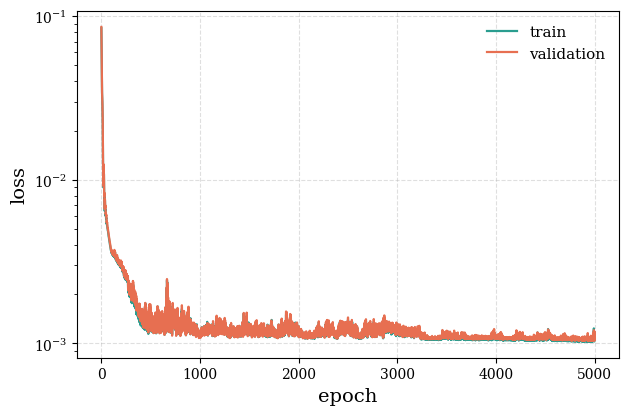

In [4]:
# loss curves from YOUR training (saved by MLQGPS.ipynb)

loss_tr = os.path.join(WDIR, "Loss_all.npy")
loss_va = os.path.join(WDIR, "Loss_validation.npy")
if os.path.isfile(loss_tr):
    ytr = np.load(loss_tr)
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(np.arange(1, len(ytr) + 1), ytr, color="#2A9D8F", lw=1.6, label="train")
    if os.path.isfile(loss_va):
        yva = np.load(loss_va)
        ax.plot(np.arange(1, len(yva) + 1), yva, color="#E76F51", lw=1.6, label="validation")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_yscale("log")
    ax.grid(True, ls="--", alpha=0.4)
    ax.legend(frameon=False)
    savefig(fig, "loss_curve.png")
else:
    print("no Loss_all.npy in", WDIR, "— skip loss plot")

saved d:\ML CURSOR\MLQGP\mlqgps_fit_plots\fit_scaled.png


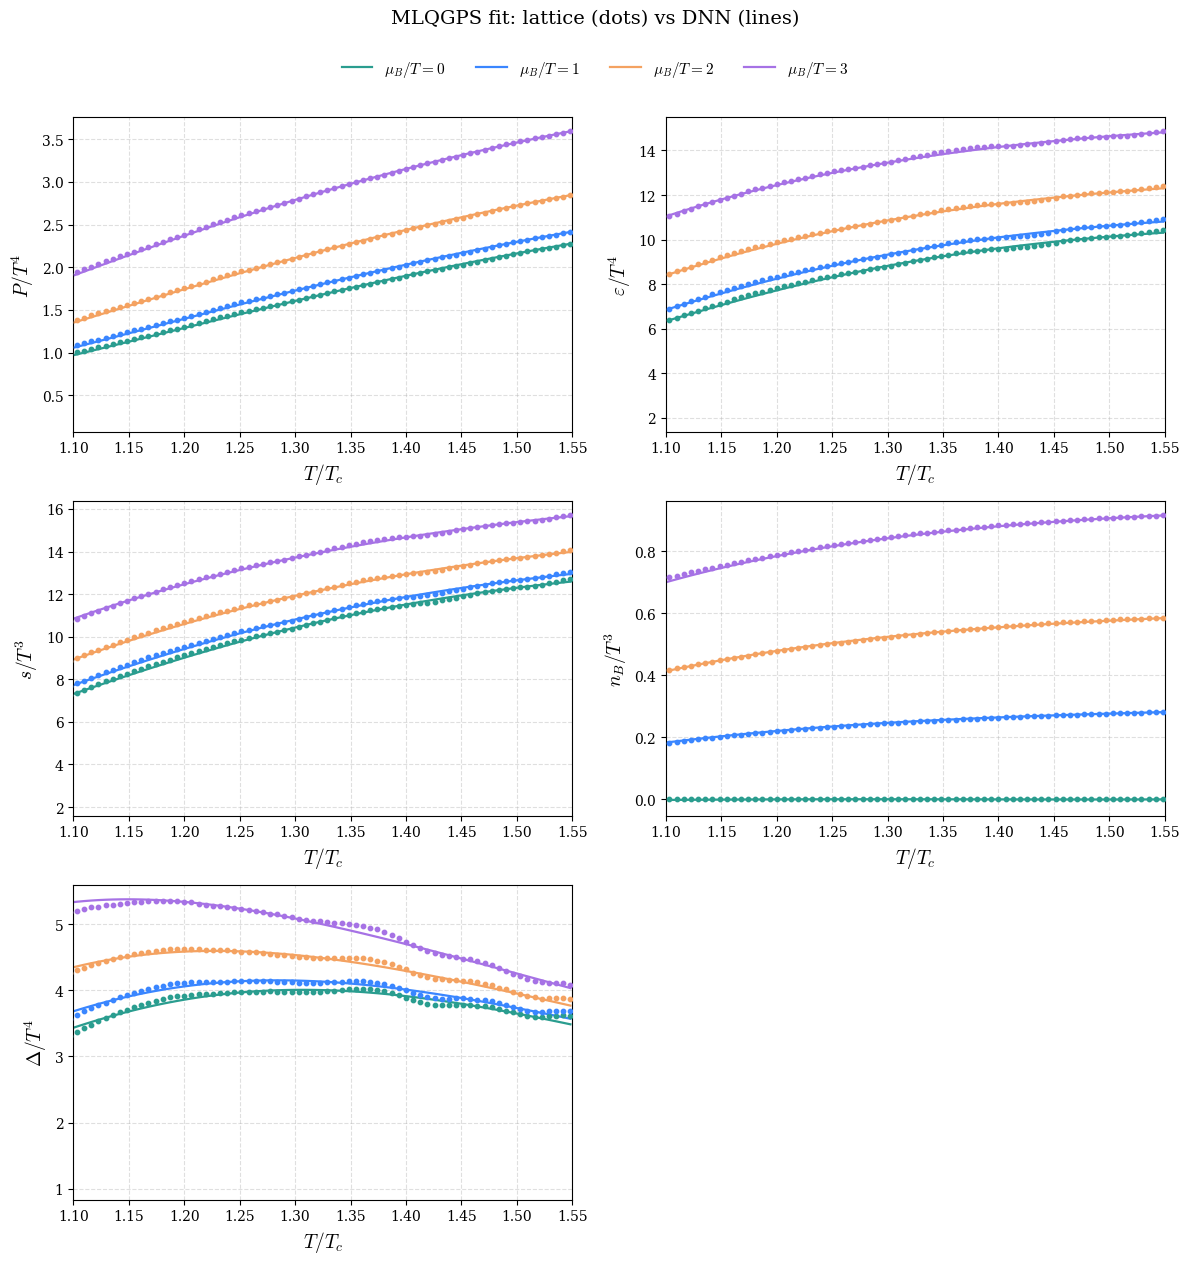

In [5]:
# fitting: lattice (dots) vs DNN (lines) on YOUR CSV, scaled observables

panels = [
    ("P/T^4", "PT4_dnn", r"$P/T^4$"),
    ("E/T^4", "ET4_dnn", r"$\varepsilon/T^4$"),
    ("s/T^3", "sT3_dnn", r"$s/T^3$"),
    ("nB/T^3", "nBT3_dnn", r"$n_B/T^3$"),
    ("TraceA", "DeltaT4_dnn", r"$\Delta/T^4$"),
]

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()
for ax, (lat, dnn, ylab) in zip(axes, panels):
    for h in MUHAT_LINES:
        sub = df[np.isclose(muhat_all, h, atol=1e-3)].sort_values("T")
        if sub.empty:
            continue
        x = sub["T"].to_numpy() / Tc
        c = COLORS[h]
        ax.scatter(x, sub[lat], s=10, color=c, zorder=3)
        ax.plot(x, sub[dnn], color=c, lw=1.6, label=rf"$\mu_B/T={int(h)}$")
    ax.set_xlabel(r"$T/T_c$")
    ax.set_ylabel(ylab)
    ax.set_xlim(1.10, 1.55)
    ax.grid(True, ls="--", alpha=0.4)
axes[-1].axis("off")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("MLQGPS fit: lattice (dots) vs DNN (lines)", y=1.05, fontsize=14)
plt.tight_layout()
savefig(fig, "fit_scaled.png")

saved d:\ML CURSOR\MLQGP\mlqgps_fit_plots\fit_raw.png


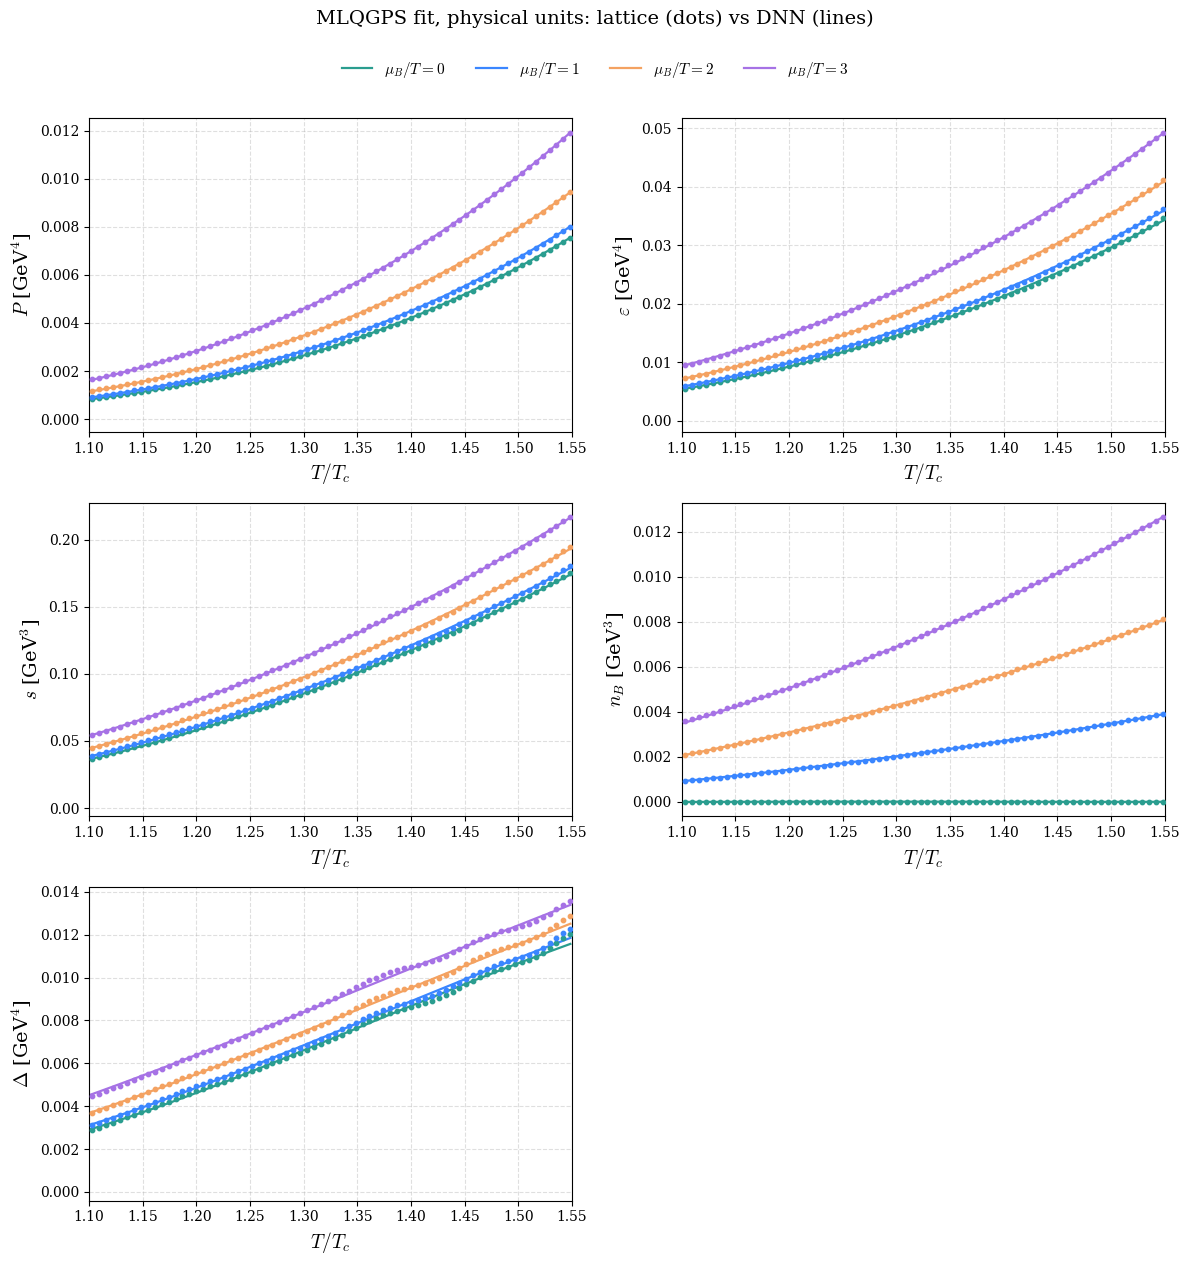

In [6]:
# fitting in physical units (same style as your first models)

raw_panels = [
    ("P/T^4", 4, "P_dnn", r"$P$ [GeV$^4$]"),
    ("E/T^4", 4, "E_dnn", r"$\varepsilon$ [GeV$^4$]"),
    ("s/T^3", 3, "s_dnn", r"$s$ [GeV$^3$]"),
    ("nB/T^3", 3, "nB_dnn", r"$n_B$ [GeV$^3$]"),
    ("TraceA", 4, "Delta_dnn", r"$\Delta$ [GeV$^4$]"),
]

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()
for ax, (lat, pwr, dnn, ylab) in zip(axes, raw_panels):
    for h in MUHAT_LINES:
        sub = df[np.isclose(muhat_all, h, atol=1e-3)].sort_values("T")
        if sub.empty:
            continue
        T = sub["T"].to_numpy()
        x = T / Tc
        c = COLORS[h]
        ax.scatter(x, sub[lat].to_numpy() * T ** pwr, s=10, color=c, zorder=3)
        ax.plot(x, sub[dnn], color=c, lw=1.6, label=rf"$\mu_B/T={int(h)}$")
    ax.set_xlabel(r"$T/T_c$")
    ax.set_ylabel(ylab)
    ax.set_xlim(1.10, 1.55)
    ax.grid(True, ls="--", alpha=0.4)
axes[-1].axis("off")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("MLQGPS fit, physical units: lattice (dots) vs DNN (lines)", y=1.05, fontsize=14)
plt.tight_layout()
savefig(fig, "fit_raw.png")

saved d:\ML CURSOR\MLQGP\mlqgps_fit_plots\mass_ud.png


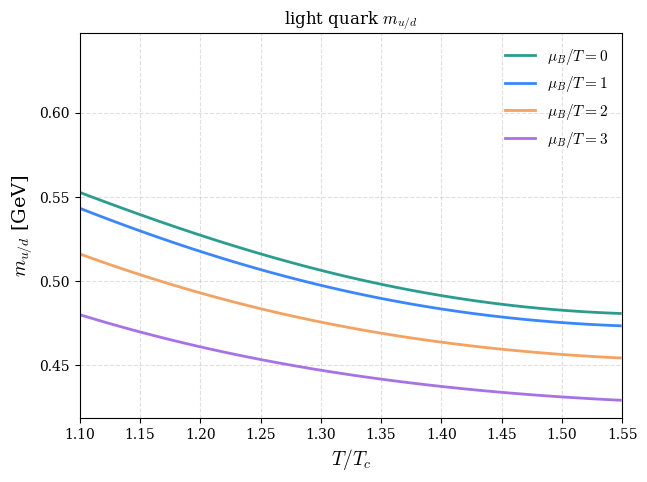

saved d:\ML CURSOR\MLQGP\mlqgps_fit_plots\mass_s.png


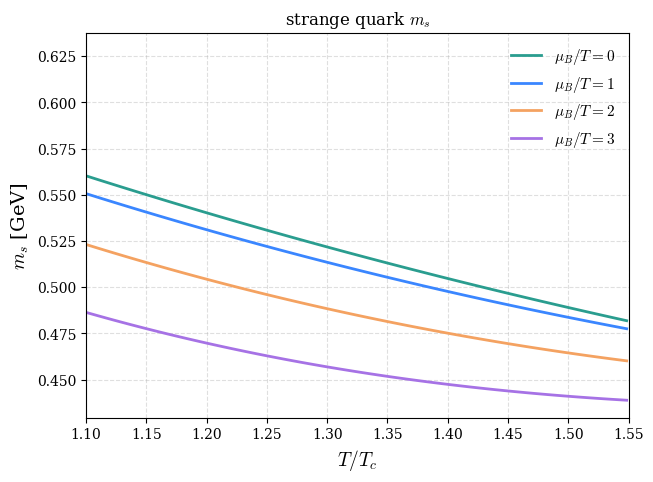

saved d:\ML CURSOR\MLQGP\mlqgps_fit_plots\mass_g.png


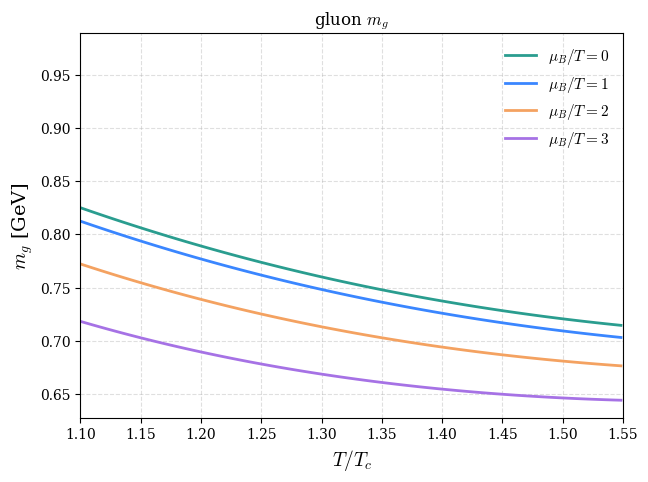

saved d:\ML CURSOR\MLQGP\mlqgps_fit_plots\mass_three_panel.png


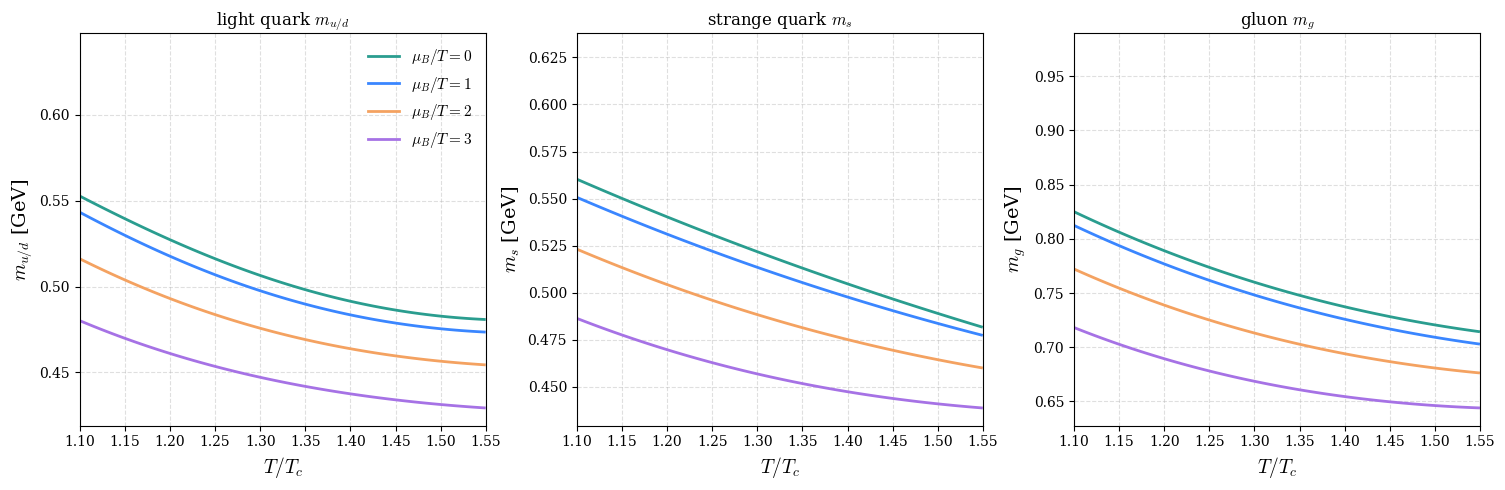

In [8]:
# masses vs T, one figure per species (YOUR DNN, YOUR CSV T)

mass_specs = [
    ("mud", r"$m_{u/d}$ [GeV]", "mass_ud.png", r"light quark $m_{u/d}$"),
    ("ms",  r"$m_s$ [GeV]",     "mass_s.png",  r"strange quark $m_s$"),
    ("mg",  r"$m_g$ [GeV]",     "mass_g.png",  r"gluon $m_g$"),
]

for col, ylab, fname, title in mass_specs:
    fig, ax = plt.subplots(figsize=(7, 5))
    for h in MUHAT_LINES:
        sub = df[np.isclose(muhat_all, h, atol=1e-3)].sort_values("T")
        if sub.empty:
            continue
        ax.plot(sub["T"] / Tc, sub[col], color=COLORS[h], lw=2.0,
                label=rf"$\mu_B/T={int(h)}$")
    ax.set_xlabel(r"$T/T_c$")
    ax.set_ylabel(ylab)
    ax.set_xlim(1.10, 1.55)
    ax.set_title(title)
    ax.grid(True, ls="--", alpha=0.4)
    ax.legend(frameon=False)
    savefig(fig, fname)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (col, ylab, _, title) in zip(axes, mass_specs):
    for h in MUHAT_LINES:
        sub = df[np.isclose(muhat_all, h, atol=1e-3)].sort_values("T")
        if sub.empty:
            continue
        ax.plot(sub["T"] / Tc, sub[col], color=COLORS[h], lw=2.0,
                label=rf"$\mu_B/T={int(h)}$")
    ax.set_xlabel(r"$T/T_c$")
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.set_xlim(1.10, 1.55)
    ax.grid(True, ls="--", alpha=0.4)
axes[0].legend(frameon=False)
plt.tight_layout()
savefig(fig, "mass_three_panel.png")

In [10]:
# dump YOUR DNN masses on YOUR CSV rows

out_csv = os.path.join(OUT, "mlqgps_masses_on_csv.csv")
df[["T", "MuB", "MuB/T", "mud", "ms", "mg",
    "s/T^3", "sT3_dnn", "P/T^4", "PT4_dnn",
    "E/T^4", "ET4_dnn", "nB/T^3", "nBT3_dnn",
    "TraceA", "DeltaT4_dnn"]].to_csv(out_csv, index=False)
print("wrote", out_csv)
print("plots in", OUT)
print(sorted(os.listdir(OUT)))

wrote d:\ML CURSOR\MLQGP\mlqgps_fit_plots\mlqgps_masses_on_csv.csv
plots in d:\ML CURSOR\MLQGP\mlqgps_fit_plots
['fit_mae.csv', 'fit_raw.png', 'fit_scaled.png', 'fit_scatter.png', 'loss_curve.png', 'mass_band.png', 'mass_band_mg.png', 'mass_band_ms.png', 'mass_band_mud.png', 'mass_g.png', 'mass_s.png', 'mass_three_panel.png', 'mass_ud.png', 'mlqgps_masses_on_csv.csv']
